<a href="https://colab.research.google.com/github/aaiissss/Machine-Learning/blob/Pertemuan05/tugas05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

2. Membaca Dataset

In [ ]:
from sklearn.datasets import load_iris

# Load dataset iris bawaan sklearn
iris = load_iris()

# Ubah ke bentuk DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species'] = df['species'].map({0: 'Iris-setosa', 1: 'Iris-versicolor', 2: 'Iris-virginica'})

# Tampilkan beberapa baris pertama
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


3. Pisahkan Fitur dan Target

In [ ]:
# Fitur (X) dan target (y)
feature_cols = iris.feature_names
X = df[feature_cols]
y = df['species']

4. Bagi Dataset (80% Training, 20% Testing)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

len(X_train), len(X_test)

(120, 30)

5. Bangun Model Decision Tree

In [ ]:
dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

6. Evaluasi Model

In [ ]:
# Prediksi data uji
y_pred = dt.predict(X_test)

# Evaluasi hasil
print("Akurasi:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Akurasi: 93.33 %

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



7. Visualisasi Pohon Keputusan

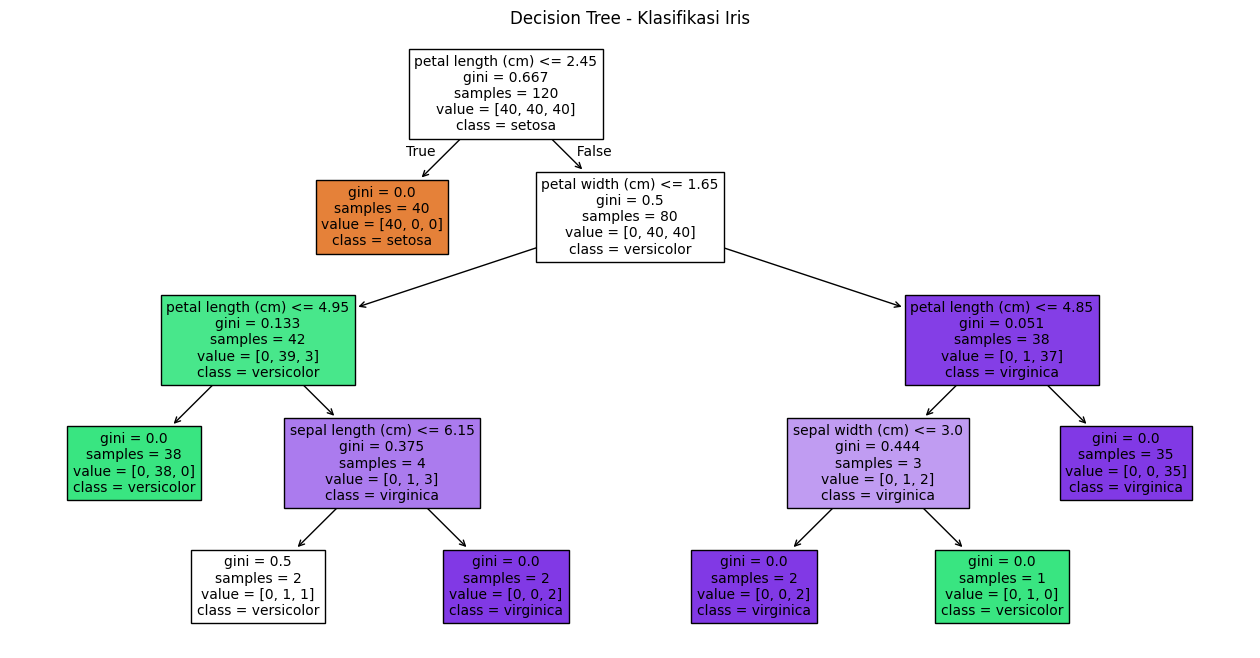

In [ ]:
plt.figure(figsize=(16,8))
plot_tree(
    dt,
    feature_names=feature_cols,
    class_names=iris.target_names,
    filled=True,
    fontsize=10
)
plt.title("Decision Tree - Klasifikasi Iris")
plt.show()

8. Analisis fitur yang paling penting

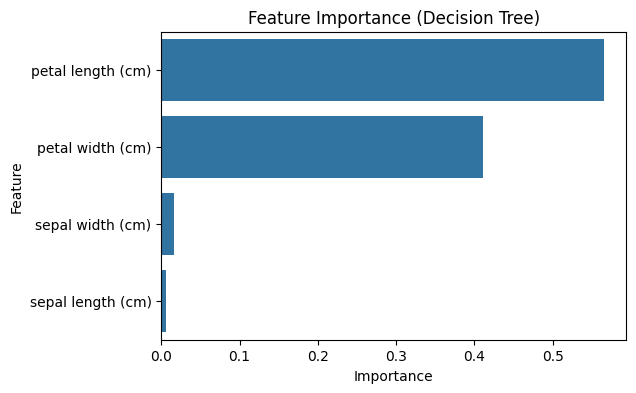

,0
petal length (cm),0.565639
petal width (cm),0.411154
sepal width (cm),0.016878
sepal length (cm),0.006329


In [ ]:
imp = pd.Series(dt.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(6,4))
sns.barplot(x=imp, y=imp.index)
plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

imp


Output yang Diharapkan :

Nilai akurasi model (biasanya sekitar 95–100%).

Confusion matrix untuk melihat performa tiap kelas.

Gambar pohon keputusan (Decision Tree).

Grafik feature importance (fitur mana paling berpengaruh).